# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0 , resnet50 ,mobilenet_v2
from tensorflow.keras.layers import Dropout , Dense , BatchNormalization , ReLU
from tensorflow.keras import models, layers, optimizers, callbacks, preprocessing, applications,Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from warnings import filterwarnings
filterwarnings("ignore")
import os
import json
import cv2
import re
IMG_SIZE = 224
BATCH_SIZE = 32
MAX_TOKENS = 5000
MAX_LEN = 25

# Build CNN + RNN Captioning Model

In [19]:
cnn_model.trainable = False

vocab = vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocab)

print("Vocabulary size:", VOCAB_SIZE)
print("MAX_LEN:", MAX_LEN)

Vocabulary size: 5000
MAX_LEN: 25


In [20]:
image_input = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
text_input  = tf.keras.layers.Input(shape=(MAX_LEN - 1,), name="decoder_input")

img_feat = cnn_model(image_input)

if len(img_feat.shape) == 4:
    img_feat = tf.keras.layers.GlobalAveragePooling2D()(img_feat)

img_feat = tf.keras.layers.Dense(256, activation="relu")(img_feat)
img_feat = tf.keras.layers.Dropout(0.2)(img_feat)

img_context = tf.keras.layers.RepeatVector(MAX_LEN - 1)(img_feat)

x = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=256,
    mask_zero=False,   
    name="token_embedding"
)(text_input)

x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Concatenate(axis=-1)([x, img_context])

x = tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.2)(x)
x = tf.keras.layers.LayerNormalization()(x)

x = tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.2)(x)
x = tf.keras.layers.LayerNormalization()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

output = tf.keras.layers.Dense(VOCAB_SIZE, activation="softmax", name="word_output")(x)

caption_model = tf.keras.Model(
    inputs=[image_input, text_input],
    outputs=output,
    name="cnn_rnn_caption_model"
)

caption_model.summary()

Model: "cnn_rnn_caption_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch          │ (None, 256)       │  4,378,531 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ cnn_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 24, 256)   │  1,280,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 256)   │          0 │ token_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 256)   │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 512)   │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 256)   │    787,456 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 256)   │        512 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 256)   │    525,312 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 256)   │        512 │ lstm_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 256)   │     65,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 256)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_output (Dense) │ (None, 24, 5000)  │  1,285,000 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,388,907 (32.00 MB)

 Trainable params: 4,010,376 (15.30 MB)

 Non-trainable params: 4,378,531 (16.70 MB)

#  Compile Model

In [21]:
caption_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    weighted_metrics=["sparse_categorical_accuracy"]
)

# Training Callbacks

In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_rnn_caption.keras",
    monitor="val_sparse_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

# Train Model 

In [23]:
history = caption_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/15


E0000 00:00:1776767949.165715      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_rnn_caption_model_1/cnn_branch_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776767951.324602      78 cuda_dnn.cc:529] Loaded cuDNN version 91002


626/626 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 2.4264 - sparse_categorical_accuracy: 0.2062
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.31398, saving model to best_cnn_rnn_caption.keras
626/626 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - loss: 2.4260 - sparse_categorical_accuracy: 0.2063 - val_loss: 1.9789 - val_sparse_categorical_accuracy: 0.3140 - learning_rate: 0.0010
Epoch 2/15
625/626 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.9133 - sparse_categorical_accuracy: 0.3120
Epoch 2: val_sparse_categorical_accuracy improved from 0.31398 to 0.33311, saving model to best_cnn_rnn_caption.keras
626/626 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - loss: 1.9131 - sparse_categorical_accuracy: 0.3120 - val_loss: 1.8345 - val_sparse_categorical_accuracy: 0.3331 - learning_rate: 0.0010
Epoch 3/15
625/626 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.7691 - sparse_categorical_accuracy: 0.3342
Epoch 3: val_sparse_categorical_accuracy improved from 0.33311 to 0.34778, saving model to best_c

# Fine-Tune Last Layers of CNN

In [24]:
cnn_model.trainable = True

for layer in cnn_model.layers[:-20]:
    layer.trainable = False

caption_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    weighted_metrics=["sparse_categorical_accuracy"]
)

history_ft = caption_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/8


E0000 00:00:1776768819.012155      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_rnn_caption_model_1/cnn_branch_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


626/626 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 1.4190 - sparse_categorical_accuracy: 0.3941
Epoch 1: val_sparse_categorical_accuracy improved from 0.40100 to 0.40340, saving model to best_cnn_rnn_caption.keras
626/626 ━━━━━━━━━━━━━━━━━━━━ 232s 308ms/step - loss: 1.4188 - sparse_categorical_accuracy: 0.3942 - val_loss: 1.5906 - val_sparse_categorical_accuracy: 0.4034 - learning_rate: 1.0000e-05
Epoch 2/8
626/626 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 1.3590 - sparse_categorical_accuracy: 0.4017
Epoch 2: val_sparse_categorical_accuracy improved from 0.40340 to 0.40641, saving model to best_cnn_rnn_caption.keras
626/626 ━━━━━━━━━━━━━━━━━━━━ 189s 303ms/step - loss: 1.3589 - sparse_categorical_accuracy: 0.4017 - val_loss: 1.5748 - val_sparse_categorical_accuracy: 0.4064 - learning_rate: 1.0000e-05
Epoch 3/8
626/626 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 1.3287 - sparse_categorical_accuracy: 0.4072
Epoch 3: val_sparse_categorical_accuracy improved from 0.40641 to 0.40813, saving 

# Visualize Training Performance

In [25]:
def merge_history(hist1, hist2=None):
    merged = {}
    for k, v in hist1.history.items():
        merged[k] = list(v)

    if hist2 is not None:
        for k, v in hist2.history.items():
            if k in merged:
                merged[k].extend(list(v))
            else:
                merged[k] = list(v)
    return merged

all_history = merge_history(history, history_ft)

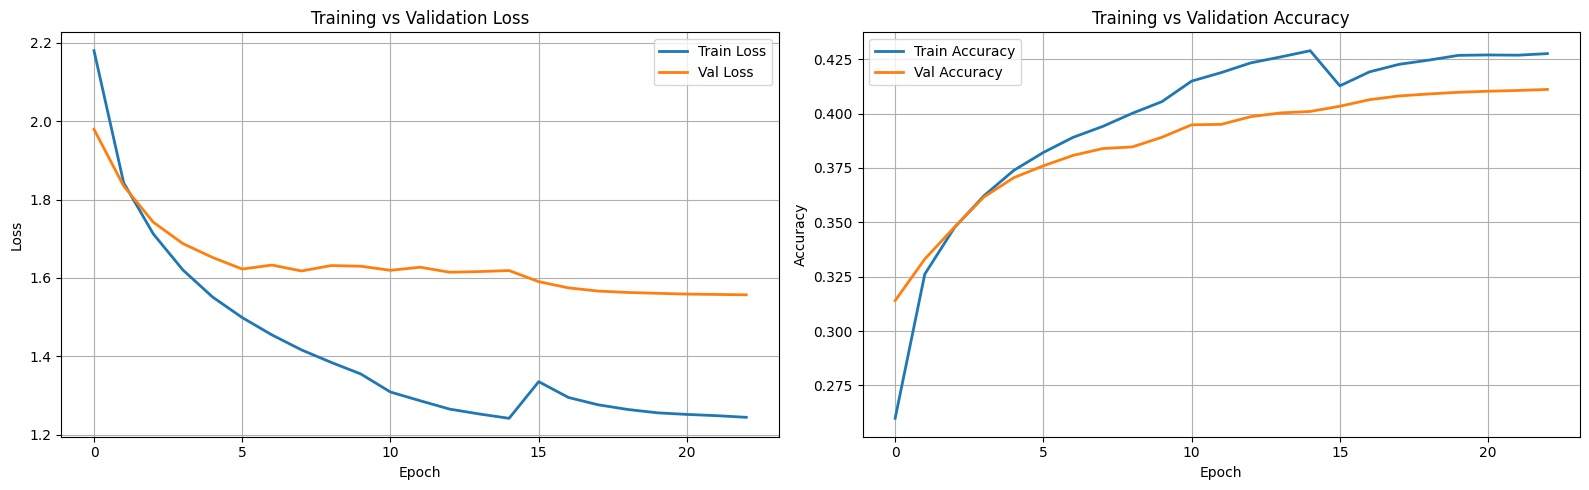

In [26]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(all_history["loss"], label="Train Loss", linewidth=2)
plt.plot(all_history["val_loss"], label="Val Loss", linewidth=2)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(all_history["sparse_categorical_accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(all_history["val_sparse_categorical_accuracy"], label="Val Accuracy", linewidth=2)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Prepare Vocabulary Helpers

In [27]:
idx_to_word = np.array(vectorizer.get_vocabulary())
word_to_idx = {word: i for i, word in enumerate(idx_to_word)}

print("Sample vocab:", idx_to_word[:20])

Sample vocab: ['' '[UNK]' 'a' '<start>' '<end>' 'on' 'of' 'the' 'in' 'with' 'and' 'is'
 'to' 'man' 'sitting' 'two' 'an' 'standing' 'people' 'at']


In [28]:
start_token = word_to_idx.get("<start>", None)
end_token   = word_to_idx.get("<end>", None)

print("start_token:", start_token)
print("end_token  :", end_token)

start_token: 3
end_token  : 4


#  Greedy Caption Generation

In [29]:
def generate_caption(image_path, model, max_len=MAX_LEN):
    img = preprocess_image(tf.constant(image_path))
    img = tf.expand_dims(img, axis=0)

    decoded = []

    if start_token is not None:
        decoded.append(start_token)

    for _ in range(max_len - 1):
        padded = tf.keras.preprocessing.sequence.pad_sequences(
            [decoded], maxlen=max_len - 1, padding="post"
        )

        preds = model.predict([img, padded], verbose=0)
        step_index = max(len(decoded) - 1, 0)
        next_token = int(np.argmax(preds[0, step_index]))

        if next_token == 0:
            break
        if end_token is not None and next_token == end_token:
            break

        decoded.append(next_token)

    words = []
    for token_id in decoded:
        if token_id == 0:
            continue
        if start_token is not None and token_id == start_token:
            continue
        if end_token is not None and token_id == end_token:
            continue

        word = idx_to_word[token_id]
        if word not in ["<start>", "<end>"]:
            words.append(word)

    return " ".join(words)

# Visualize Predicted Captions

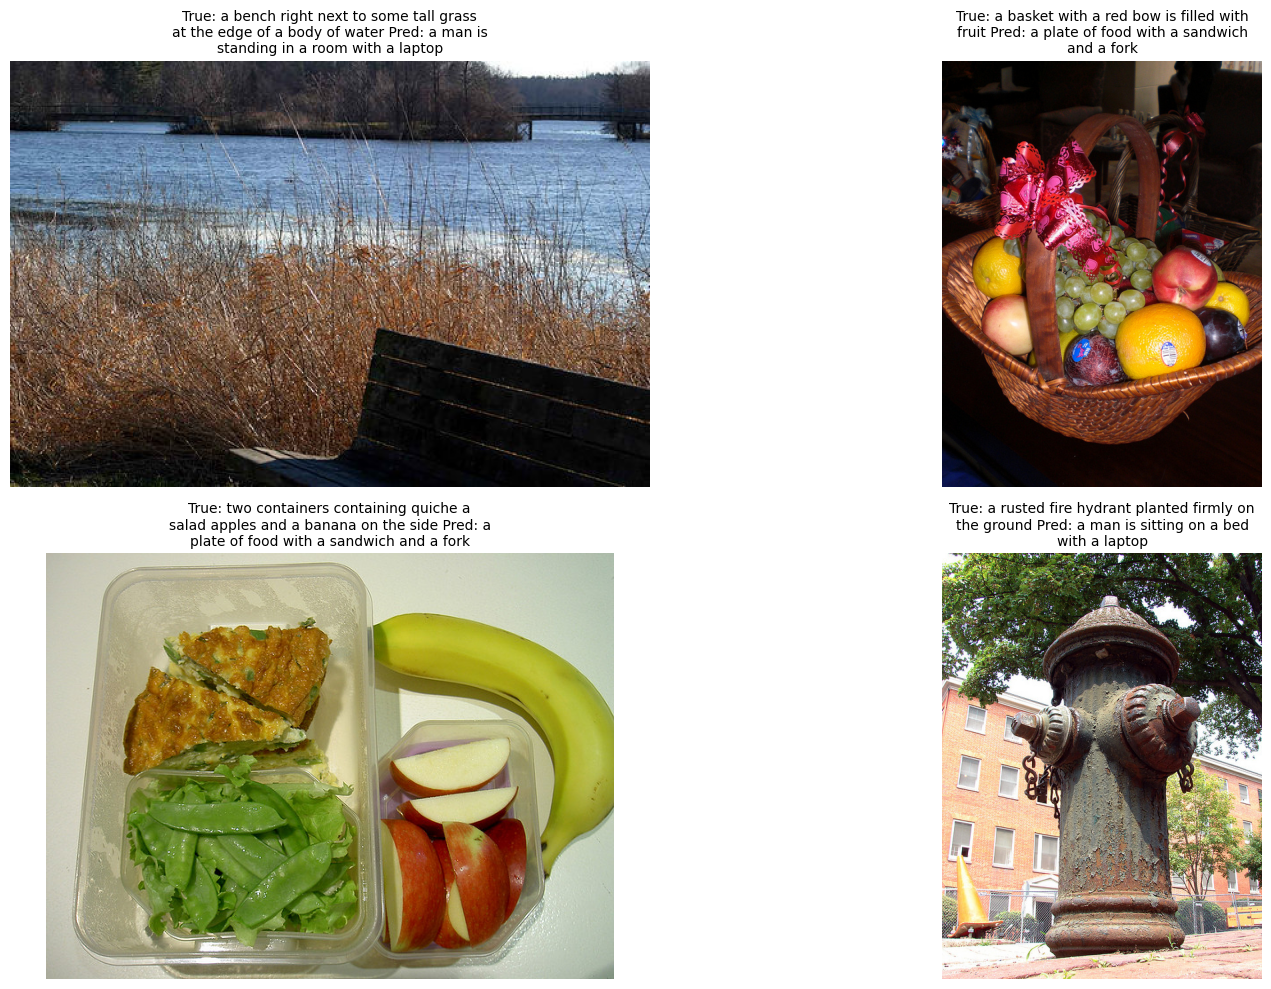

In [30]:
sample_vis_df = val_df.sample(4, random_state=42).reset_index(drop=True)

plt.figure(figsize=(18, 10))

for i, row in sample_vis_df.iterrows():
    img_path = row["image_path"]
    true_caption = row["caption"]
    pred_caption = generate_caption(img_path, caption_model)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    true_caption = true_caption.replace("<start>", "").replace("<end>", "").strip()

    title_text = f"True: {true_caption}\nPred: {pred_caption}"
    title_text = "\n".join(textwrap.wrap(title_text, width=45))

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(title_text, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Show One Random Example

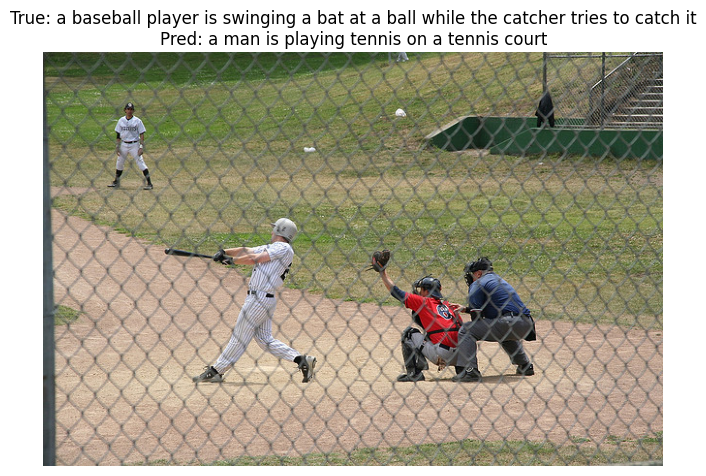

In [31]:
random_row = val_df.sample(1).iloc[0]

img_path = random_row["image_path"]
true_caption = random_row["caption"].replace("<start>", "").replace("<end>", "").strip()
pred_caption = generate_caption(img_path, caption_model)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"True: {true_caption}\nPred: {pred_caption}", fontsize=12)
plt.axis("off")
plt.show()

#  Final Evaluation

In [32]:
results = caption_model.evaluate(val_ds, verbose=1)

print("\nValidation Loss     :", results[0])
print("Validation Accuracy :", results[1])

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 1.5646 - sparse_categorical_accuracy: 0.4048

Validation Loss     : 1.5570415258407593
Validation Accuracy : 0.4111276865005493
